# Verification of the scenario data files

These data files include RMa, UMi, UMa files.

## 1. Imports and File Directories

In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import sionna
import h5py
import pandas as pd
import seaborn as sns

DATA_DIR = '../data/'

RMA_FILE = DATA_DIR + 'Rma.h5'
UMA_FILE = DATA_DIR + 'Uma.h5'
UMI_FILE = DATA_DIR + 'Umi.h5'

FILES = [RMA_FILE, UMA_FILE, UMI_FILE]

from pathlib import Path

for file in FILES:

    file_path = Path(file)

    file_size = file_path.stat().st_size

    print(file, file_size , "bytes")
    print(file, file_size / 1048576, "megabytes")

../data/Rma.h5 746990712 bytes
../data/Rma.h5 712.385856628418 megabytes
../data/Uma.h5 747428440 bytes
../data/Uma.h5 712.8033065795898 megabytes
../data/Umi.h5 747418280 bytes
../data/Umi.h5 712.7936172485352 megabytes


## 2. Opening each file and initial global sanity checks

In [2]:
for file in FILES:

    with h5py.File(file, 'r') as f:

        print("* " * 5 + file + "* " * 5)

        print("Data")
        print(f["Data"].shape, f["Data"].dtype)

        print("Mods")
        print(f["Mods"].shape, f["Mods"].dtype)

        print("SNRs")
        print(f["SNRs"].shape)

        
        print(f["Mods"][:].sum(axis=1).min(), f["Mods"][:].sum(axis=1).max())



* * * * * ../data/Rma.h5* * * * * 
Data
(98304, 1024) complex64
Mods
(98304, 6) float32
SNRs
(98304,)
1.0 1.0
* * * * * ../data/Uma.h5* * * * * 
Data
(98304, 1024) complex64
Mods
(98304, 6) float32
SNRs
(98304,)
1.0 1.0
* * * * * ../data/Umi.h5* * * * * 
Data
(98304, 1024) complex64
Mods
(98304, 6) float32
SNRs
(98304,)
1.0 1.0


## 3. Checking for NaNs and Infs

In [3]:
for file in FILES:

    print(file)

    with h5py.File(file, 'r') as f:

        data = f["Data"][:]
        print(f"Data - NaNs: {np.isnan(data).any()}, Infs: {np.isinf(data).any()}")
            
        mods = f["Mods"][:]
        print(f"Mods - NaNs: {np.isnan(mods).any()}, Infs: {np.isinf(mods).any()}")
            
        snrs = f["SNRs"][:]
        print(f"SNRs - NaNs: {np.isnan(snrs).any()}, Infs: {np.isinf(snrs).any()}")

../data/Rma.h5
Data - NaNs: False, Infs: False
Mods - NaNs: False, Infs: False
SNRs - NaNs: False, Infs: False
../data/Uma.h5
Data - NaNs: False, Infs: False
Mods - NaNs: False, Infs: False
SNRs - NaNs: False, Infs: False
../data/Umi.h5
Data - NaNs: False, Infs: False
Mods - NaNs: False, Infs: False
SNRs - NaNs: False, Infs: False


## 4. Label Integrity & Balancing

In [4]:
MOD_NAMES = ['BPSK', 'QPSK', '16QAM', '64QAM', '256QAM', '1024QAM']

with h5py.File(file, 'r') as f:

    snrs = f["SNRs"][:]

    unique_snrs = np.unique(snrs)
    print(f"Unique SNRs ({len(unique_snrs)} total): {unique_snrs}\n")

    mods = f["Mods"][:]

    row_sums = mods.sum(axis=1)

    n_exact = np.sum(row_sums == 1.0)
    n_close = np.sum(np.isclose(row_sums, 1.0, atol=1e-5))
    n_total = len(row_sums)

    is_one_hot = np.all(np.isin(mods, [0.0, 1.0])) and np.all(row_sums == 1.0)

    print("* " * 5 + file + " * " * 5)
    print(f"Rows: {n_total}")
    print(f"  Sum exactly 1.0: {n_exact}/{n_total}")
    print(f"  Sum close to 1.0 (atol=1e-5): {n_close}/{n_total}")
    print(f"  Strict one-hot (only 0/1 values, single 1 per row): {is_one_hot}")

    if n_exact != n_total:
        bad_idx = np.where(row_sums != 1.0)[0]
        print(f"  WARNING: {len(bad_idx)} bad rows, e.g. indices {bad_idx[:10]}")
        print(f"  Example bad row sums: {row_sums[bad_idx[:5]]}")
    print()


Unique SNRs (16 total): [-10.  -8.  -6.  -4.  -2.   0.   2.   4.   6.   8.  10.  12.  14.  16.
  18.  20.]

* * * * * ../data/Umi.h5 *  *  *  *  * 
Rows: 98304
  Sum exactly 1.0: 98304/98304
  Sum close to 1.0 (atol=1e-5): 98304/98304
  Strict one-hot (only 0/1 values, single 1 per row): True



## 5. Modulation One-Hot Check

In [6]:
EXPECTED_SNRS = np.arange(-10, 21, 2)  # -10, -8, ..., 20 -> 16 values

for file in FILES:
    with h5py.File(file, 'r') as f:
        snrs = f["SNRs"][:]

        unique_snrs, counts = np.unique(snrs, return_counts=True)

        print("* " * 5 + file + " * " * 5)
        print(f"Unique SNR count: {len(unique_snrs)} (expected 16)")
        print(f"Unique SNR values: {unique_snrs}")
        print(f"Matches expected -10..20 step 2: {np.array_equal(unique_snrs, EXPECTED_SNRS)}")
        print(f"Per-SNR sample counts: {dict(zip(unique_snrs, counts))}")
        print(f"All counts equal (6144 expected, i.e. 98304/16): {len(set(counts)) == 1}")
        print()

* * * * * ../data/Rma.h5 *  *  *  *  * 
Unique SNR count: 16 (expected 16)
Unique SNR values: [-10.  -8.  -6.  -4.  -2.   0.   2.   4.   6.   8.  10.  12.  14.  16.
  18.  20.]
Matches expected -10..20 step 2: True
Per-SNR sample counts: {np.float32(-10.0): np.int64(6144), np.float32(-8.0): np.int64(6144), np.float32(-6.0): np.int64(6144), np.float32(-4.0): np.int64(6144), np.float32(-2.0): np.int64(6144), np.float32(0.0): np.int64(6144), np.float32(2.0): np.int64(6144), np.float32(4.0): np.int64(6144), np.float32(6.0): np.int64(6144), np.float32(8.0): np.int64(6144), np.float32(10.0): np.int64(6144), np.float32(12.0): np.int64(6144), np.float32(14.0): np.int64(6144), np.float32(16.0): np.int64(6144), np.float32(18.0): np.int64(6144), np.float32(20.0): np.int64(6144)}
All counts equal (6144 expected, i.e. 98304/16): True

* * * * * ../data/Uma.h5 *  *  *  *  * 
Unique SNR count: 16 (expected 16)
Unique SNR values: [-10.  -8.  -6.  -4.  -2.   0.   2.   4.   6.   8.  10.  12.  14.  16.
 

## 7. Step 2.3 — Cross-Tabulation Matrix (SNR vs Modulation)

* * * * * ../data/Rma.h5 *  *  *  *  * 
Mod    BPSK  QPSK  16QAM  64QAM  256QAM  1024QAM
SNR                                             
-10.0  1024  1024   1024   1024    1024     1024
-8.0   1024  1024   1024   1024    1024     1024
-6.0   1024  1024   1024   1024    1024     1024
-4.0   1024  1024   1024   1024    1024     1024
-2.0   1024  1024   1024   1024    1024     1024
 0.0   1024  1024   1024   1024    1024     1024
 2.0   1024  1024   1024   1024    1024     1024
 4.0   1024  1024   1024   1024    1024     1024
 6.0   1024  1024   1024   1024    1024     1024
 8.0   1024  1024   1024   1024    1024     1024
 10.0  1024  1024   1024   1024    1024     1024
 12.0  1024  1024   1024   1024    1024     1024
 14.0  1024  1024   1024   1024    1024     1024
 16.0  1024  1024   1024   1024    1024     1024
 18.0  1024  1024   1024   1024    1024     1024
 20.0  1024  1024   1024   1024    1024     1024

All cells == 1024: True


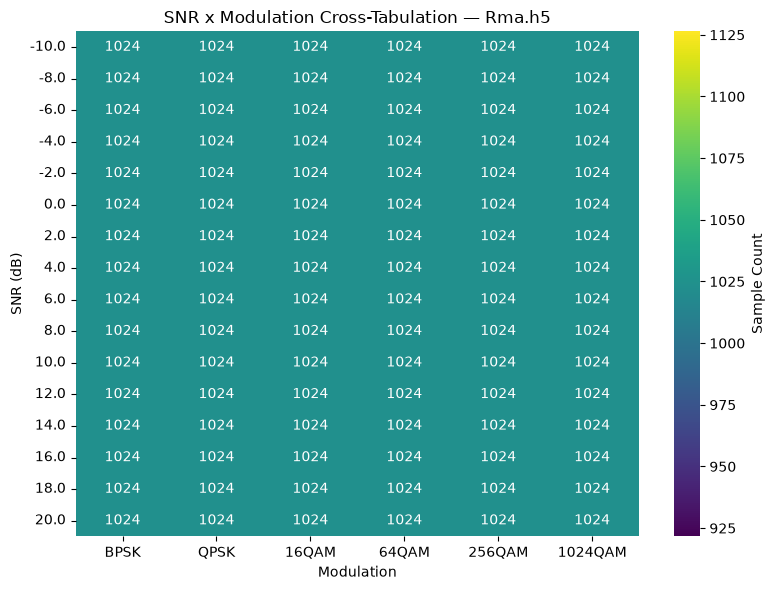


* * * * * ../data/Uma.h5 *  *  *  *  * 
Mod    BPSK  QPSK  16QAM  64QAM  256QAM  1024QAM
SNR                                             
-10.0  1024  1024   1024   1024    1024     1024
-8.0   1024  1024   1024   1024    1024     1024
-6.0   1024  1024   1024   1024    1024     1024
-4.0   1024  1024   1024   1024    1024     1024
-2.0   1024  1024   1024   1024    1024     1024
 0.0   1024  1024   1024   1024    1024     1024
 2.0   1024  1024   1024   1024    1024     1024
 4.0   1024  1024   1024   1024    1024     1024
 6.0   1024  1024   1024   1024    1024     1024
 8.0   1024  1024   1024   1024    1024     1024
 10.0  1024  1024   1024   1024    1024     1024
 12.0  1024  1024   1024   1024    1024     1024
 14.0  1024  1024   1024   1024    1024     1024
 16.0  1024  1024   1024   1024    1024     1024
 18.0  1024  1024   1024   1024    1024     1024
 20.0  1024  1024   1024   1024    1024     1024

All cells == 1024: True


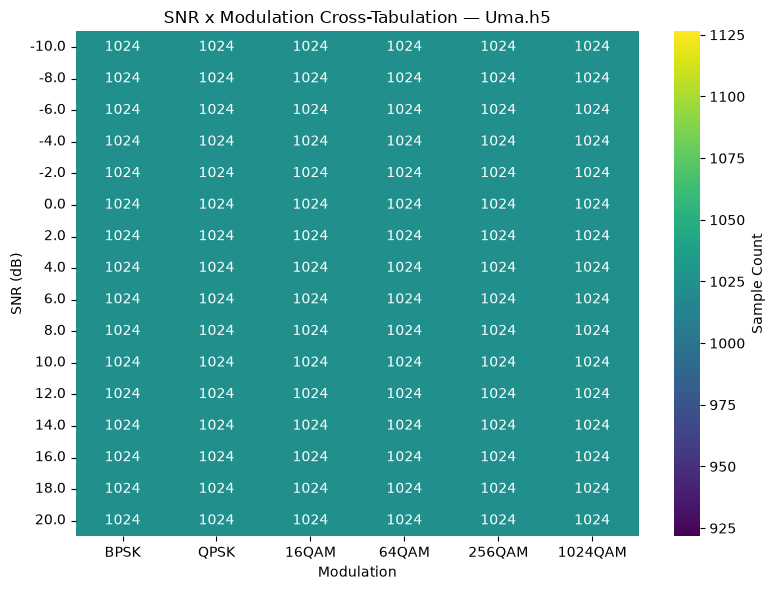


* * * * * ../data/Umi.h5 *  *  *  *  * 
Mod    BPSK  QPSK  16QAM  64QAM  256QAM  1024QAM
SNR                                             
-10.0  1024  1024   1024   1024    1024     1024
-8.0   1024  1024   1024   1024    1024     1024
-6.0   1024  1024   1024   1024    1024     1024
-4.0   1024  1024   1024   1024    1024     1024
-2.0   1024  1024   1024   1024    1024     1024
 0.0   1024  1024   1024   1024    1024     1024
 2.0   1024  1024   1024   1024    1024     1024
 4.0   1024  1024   1024   1024    1024     1024
 6.0   1024  1024   1024   1024    1024     1024
 8.0   1024  1024   1024   1024    1024     1024
 10.0  1024  1024   1024   1024    1024     1024
 12.0  1024  1024   1024   1024    1024     1024
 14.0  1024  1024   1024   1024    1024     1024
 16.0  1024  1024   1024   1024    1024     1024
 18.0  1024  1024   1024   1024    1024     1024
 20.0  1024  1024   1024   1024    1024     1024

All cells == 1024: True


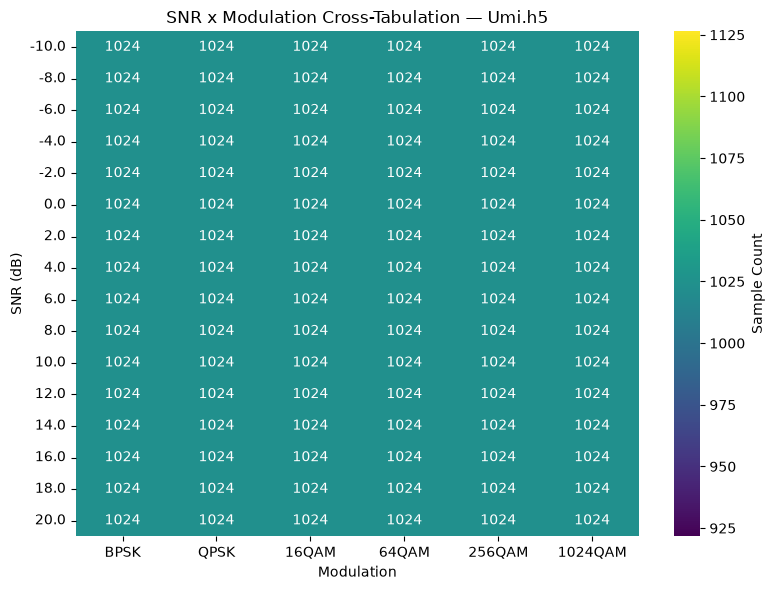

In [7]:
for file in FILES:
    with h5py.File(file, 'r') as f:
        snrs = f["SNRs"][:]
        mods = f["Mods"][:]

        mod_idx = np.argmax(mods, axis=1)
        mod_labels = np.array(MOD_NAMES)[mod_idx]

        df = pd.DataFrame({"SNR": snrs, "Mod": mod_labels})

        crosstab = pd.crosstab(df["SNR"], df["Mod"])
        crosstab = crosstab[MOD_NAMES]  # enforce column order

        print("* " * 5 + file + " * " * 5)
        print(crosstab)

        all_1024 = (crosstab.values == 1024).all()
        print(f"\nAll cells == 1024: {all_1024}")

        if not all_1024:
            bad_cells = np.argwhere(crosstab.values != 1024)
            for r, c in bad_cells:
                print(f"  MISMATCH: SNR={crosstab.index[r]}, Mod={crosstab.columns[c]}, "
                      f"count={crosstab.values[r, c]}")

        plt.figure(figsize=(8, 6))
        sns.heatmap(crosstab, annot=True, fmt='d', cmap='viridis',
                    cbar_kws={'label': 'Sample Count'})
        plt.title(f"SNR x Modulation Cross-Tabulation — {Path(file).name}")
        plt.xlabel("Modulation")
        plt.ylabel("SNR (dB)")
        plt.tight_layout()
        plt.show()
        print()

## 8. Cross-Modulation Energy Consistency @ 20 dB

In [8]:
for file in FILES:
    with h5py.File(file, 'r') as f:
        data = f["Data"][:]
        mods = f["Mods"][:]
        snrs = f["SNRs"][:]

        mod_idx = np.argmax(mods, axis=1)
        mod_labels = np.array(MOD_NAMES)[mod_idx]

        print("* " * 5 + file + " * " * 5)

        target_snr = 20.0
        mask_snr = np.isclose(snrs, target_snr)

        energies = {}
        for m in MOD_NAMES:
            mask = mask_snr & (mod_labels == m)
            sig = data[mask]  # (1024, 1024) samples x time
            mean_energy = np.mean(np.abs(sig) ** 2)
            energies[m] = mean_energy
            print(f"  {m:8s}: mean energy = {mean_energy:.4f}  (n={mask.sum()})")

        vals = np.array(list(energies.values()))
        print(f"  --> Spread: min={vals.min():.4f}, max={vals.max():.4f}, "
              f"ratio max/min={vals.max()/vals.min():.3f}")
        print()

* * * * * ../data/Rma.h5 *  *  *  *  * 
  BPSK    : mean energy = 1.8851  (n=1024)
  QPSK    : mean energy = 1.9743  (n=1024)
  16QAM   : mean energy = 1.8319  (n=1024)
  64QAM   : mean energy = 1.8520  (n=1024)
  256QAM  : mean energy = 1.8423  (n=1024)
  1024QAM : mean energy = 1.8461  (n=1024)
  --> Spread: min=1.8319, max=1.9743, ratio max/min=1.078

* * * * * ../data/Uma.h5 *  *  *  *  * 
  BPSK    : mean energy = 1.5376  (n=1024)
  QPSK    : mean energy = 1.5699  (n=1024)
  16QAM   : mean energy = 1.7036  (n=1024)
  64QAM   : mean energy = 1.4440  (n=1024)
  256QAM  : mean energy = 1.6576  (n=1024)
  1024QAM : mean energy = 1.6434  (n=1024)
  --> Spread: min=1.4440, max=1.7036, ratio max/min=1.180

* * * * * ../data/Umi.h5 *  *  *  *  * 
  BPSK    : mean energy = 1.6131  (n=1024)
  QPSK    : mean energy = 1.6210  (n=1024)
  16QAM   : mean energy = 1.5412  (n=1024)
  64QAM   : mean energy = 1.6557  (n=1024)
  256QAM  : mean energy = 1.6032  (n=1024)
  1024QAM : mean energy = 1.653

## 9. Peak-to-Average Power Ratio (PAPR)

In [9]:
def compute_papr(signal):
    """
    signal: (N, 1024) complex array
    Returns PAPR (linear, not dB) per row, then we take mean/median across rows.
    """
    power = np.abs(signal) ** 2          # (N, 1024)
    peak = np.max(power, axis=1)         # (N,)
    avg = np.mean(power, axis=1)         # (N,)
    papr_linear = peak / avg
    return papr_linear

qam_order = ['16QAM', '64QAM', '256QAM', '1024QAM']

for file in FILES:
    with h5py.File(file, 'r') as f:
        data = f["Data"][:]
        mods = f["Mods"][:]
        snrs = f["SNRs"][:]

        mod_idx = np.argmax(mods, axis=1)
        mod_labels = np.array(MOD_NAMES)[mod_idx]
        mask_snr = np.isclose(snrs, 20.0)

        qam_papr = []
        for m in qam_order:
            mask = mask_snr & (mod_labels == m)
            papr_lin = compute_papr(data[mask])
            qam_papr.append(10 * np.log10(np.mean(papr_lin)))

        is_monotonic = all(qam_papr[i] < qam_papr[i+1] for i in range(len(qam_papr)-1))
        print(f"{file}: QAM PAPR sequence = {[f'{v:.2f}' for v in qam_papr]} dB "
              f"-> monotonic increasing: {is_monotonic}")

../data/Rma.h5: QAM PAPR sequence = ['4.25', '4.88', '5.11', '5.18'] dB -> monotonic increasing: True
../data/Uma.h5: QAM PAPR sequence = ['5.79', '6.23', '6.26', '6.27'] dB -> monotonic increasing: True
../data/Umi.h5: QAM PAPR sequence = ['5.62', '6.02', '6.11', '6.13'] dB -> monotonic increasing: True


In [10]:
for file in FILES:
    with h5py.File(file, 'r') as f:
        data = f["Data"][:]
        mods = f["Mods"][:]
        snrs = f["SNRs"][:]

        mod_idx = np.argmax(mods, axis=1)
        mod_labels = np.array(MOD_NAMES)[mod_idx]
        mask_snr = np.isclose(snrs, 20.0)

        all_papr = {}
        for m in MOD_NAMES:
            mask = mask_snr & (mod_labels == m)
            papr_lin = compute_papr(data[mask])
            all_papr[m] = 10 * np.log10(np.mean(papr_lin))

        print(f"{file}: PAPR @ 20dB (dB) = " +
              ", ".join(f"{m}={all_papr[m]:.2f}" for m in MOD_NAMES))

        # explicit BPSK vs QPSK check
        bpsk_qpsk_gap = all_papr['BPSK'] - all_papr['QPSK']
        print(f"  BPSK - QPSK = {bpsk_qpsk_gap:+.2f} dB "
              f"({'BPSK higher' if bpsk_qpsk_gap > 0 else 'QPSK higher or equal'})")

        qam_papr = [all_papr[m] for m in qam_order]
        is_monotonic = all(qam_papr[i] < qam_papr[i+1] for i in range(len(qam_papr)-1))
        print(f"  QAM monotonic increasing: {is_monotonic}\n")

../data/Rma.h5: PAPR @ 20dB (dB) = BPSK=3.30, QPSK=2.74, 16QAM=4.25, 64QAM=4.88, 256QAM=5.11, 1024QAM=5.18
  BPSK - QPSK = +0.55 dB (BPSK higher)
  QAM monotonic increasing: True

../data/Uma.h5: PAPR @ 20dB (dB) = BPSK=5.06, QPSK=4.62, 16QAM=5.79, 64QAM=6.23, 256QAM=6.26, 1024QAM=6.27
  BPSK - QPSK = +0.44 dB (BPSK higher)
  QAM monotonic increasing: True

../data/Umi.h5: PAPR @ 20dB (dB) = BPSK=4.97, QPSK=4.36, 16QAM=5.62, 64QAM=6.02, 256QAM=6.11, 1024QAM=6.13
  BPSK - QPSK = +0.61 dB (BPSK higher)
  QAM monotonic increasing: True



In [11]:
for file in FILES:
    with h5py.File(file, 'r') as f:
        data = f["Data"][:]
        mods = f["Mods"][:]
        snrs = f["SNRs"][:]

        mod_idx = np.argmax(mods, axis=1)
        mod_labels = np.array(MOD_NAMES)[mod_idx]
        mask_snr = np.isclose(snrs, 20.0)

        all_papr = {}
        for m in MOD_NAMES:
            mask = mask_snr & (mod_labels == m)
            papr_lin = compute_papr(data[mask])
            all_papr[m] = 10 * np.log10(np.mean(papr_lin))

        print(f"{file}: PAPR @ 20dB (dB) = " +
              ", ".join(f"{m}={all_papr[m]:.2f}" for m in MOD_NAMES))

        # explicit BPSK vs QPSK check
        bpsk_qpsk_gap = all_papr['BPSK'] - all_papr['QPSK']
        print(f"  BPSK - QPSK = {bpsk_qpsk_gap:+.2f} dB "
              f"({'BPSK higher' if bpsk_qpsk_gap > 0 else 'QPSK higher or equal'})")

        qam_papr = [all_papr[m] for m in qam_order]
        is_monotonic = all(qam_papr[i] < qam_papr[i+1] for i in range(len(qam_papr)-1))
        print(f"  QAM monotonic increasing: {is_monotonic}\n")

../data/Rma.h5: PAPR @ 20dB (dB) = BPSK=3.30, QPSK=2.74, 16QAM=4.25, 64QAM=4.88, 256QAM=5.11, 1024QAM=5.18
  BPSK - QPSK = +0.55 dB (BPSK higher)
  QAM monotonic increasing: True

../data/Uma.h5: PAPR @ 20dB (dB) = BPSK=5.06, QPSK=4.62, 16QAM=5.79, 64QAM=6.23, 256QAM=6.26, 1024QAM=6.27
  BPSK - QPSK = +0.44 dB (BPSK higher)
  QAM monotonic increasing: True

../data/Umi.h5: PAPR @ 20dB (dB) = BPSK=4.97, QPSK=4.36, 16QAM=5.62, 64QAM=6.02, 256QAM=6.11, 1024QAM=6.13
  BPSK - QPSK = +0.61 dB (BPSK higher)
  QAM monotonic increasing: True



## 10. Step 4.1 High SNR (20 dB) Constellation Scatter Plots

In [13]:
def get_global_limit(target_snr, mods_to_check, n_symbols_per_mod=5, pad_frac=0.1):
    """
    Scans across ALL files and the given modulations at target_snr,
    returns a single symmetric axis limit (max abs value found) with padding.
    """
    global_max = 0.0
    for file in FILES:
        with h5py.File(file, 'r') as f:
            data = f["Data"][:]
            mods = f["Mods"][:]
            snrs = f["SNRs"][:]

        mod_idx = np.argmax(mods, axis=1)
        mod_labels = np.array(MOD_NAMES)[mod_idx]
        mask_snr = np.isclose(snrs, target_snr)

        for m in mods_to_check:
            mask = mask_snr & (mod_labels == m)
            sig = data[mask][:n_symbols_per_mod].flatten()
            local_max = np.max(np.abs(np.concatenate([sig.real, sig.imag])))
            global_max = max(global_max, local_max)

    return global_max * (1 + pad_frac)

PLOT_MODS = MOD_NAMES

def plot_constellations(file, target_snr, axis_limit, n_symbols_per_mod=5, title_suffix=""):
    with h5py.File(file, 'r') as f:
        data = f["Data"][:]
        mods = f["Mods"][:]
        snrs = f["SNRs"][:]

    mod_idx = np.argmax(mods, axis=1)
    mod_labels = np.array(MOD_NAMES)[mod_idx]
    mask_snr = np.isclose(snrs, target_snr)

    fig, axes = plt.subplots(1, len(PLOT_MODS), figsize=(20, 5))
    fig.suptitle(f"{Path(file).name} — Constellations @ {target_snr} dB {title_suffix}", fontsize=14)

    for ax, m in zip(axes, PLOT_MODS):
        mask = mask_snr & (mod_labels == m)
        sig = data[mask][:n_symbols_per_mod]
        flat = sig.flatten()

        ax.scatter(flat.real, flat.imag, s=2, alpha=0.3)
        ax.axhline(0, color='gray', lw=0.5)
        ax.axvline(0, color='gray', lw=0.5)
        ax.set_title(f"{m}")
        ax.set_xlabel("I")
        ax.set_ylabel("Q")
        ax.grid(alpha=0.3)
        ax.set_aspect('equal')
        ax.set_xlim(-axis_limit, axis_limit)
        ax.set_ylim(-axis_limit, axis_limit)

    plt.tight_layout()
    plt.show()

Global axis limit @ 20 dB: 8.205


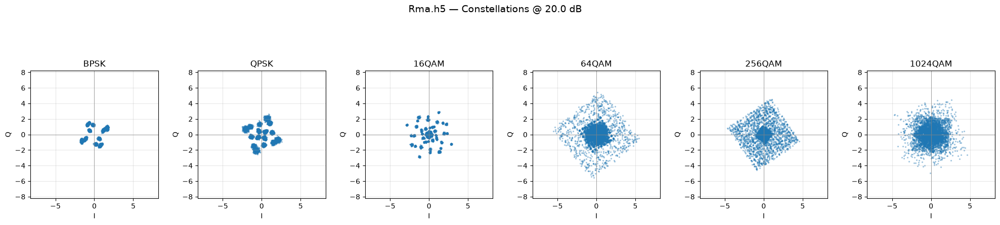

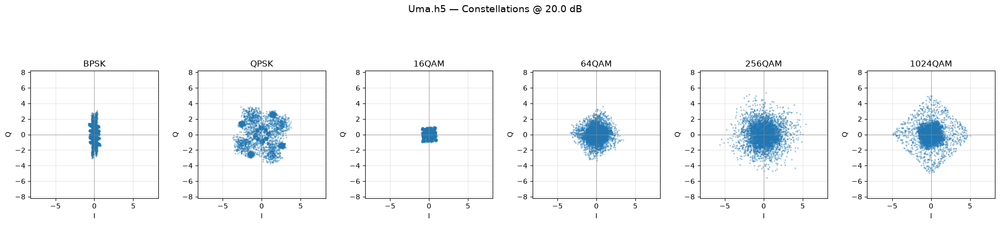

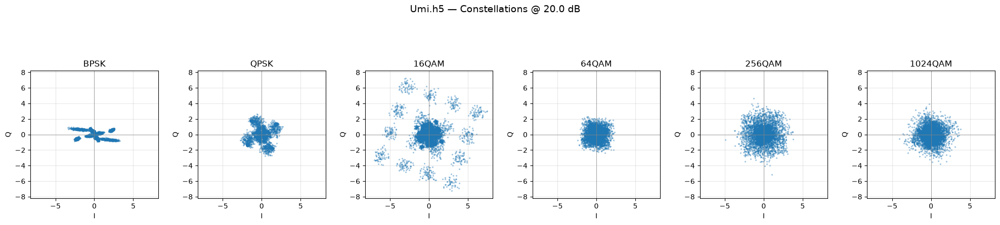

In [14]:
limit_20db = get_global_limit(target_snr = 20.0, mods_to_check=MOD_NAMES)
print(f"Global axis limit @ 20 dB: {limit_20db:.3f}")

for file in FILES:
    plot_constellations(file, target_snr=20.0, axis_limit=limit_20db, n_symbols_per_mod=5)

## 11. Step 4.2 Low SNR (-10 dB) Constellation Scatter Plots

Global axis limit @ -10 dB: 10.797


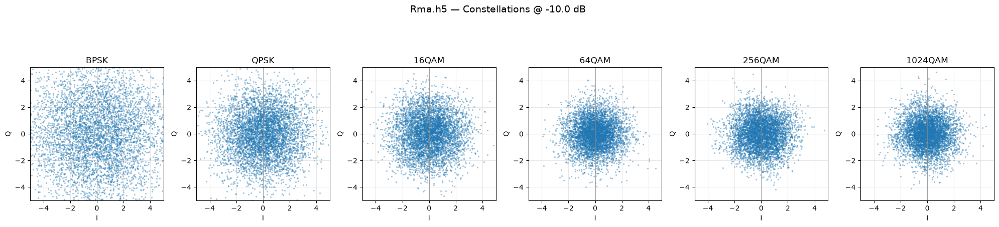

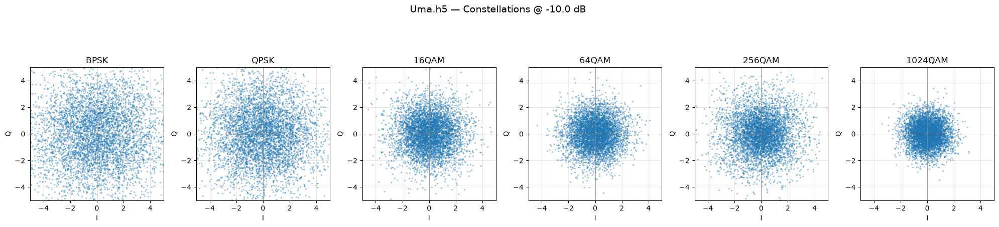

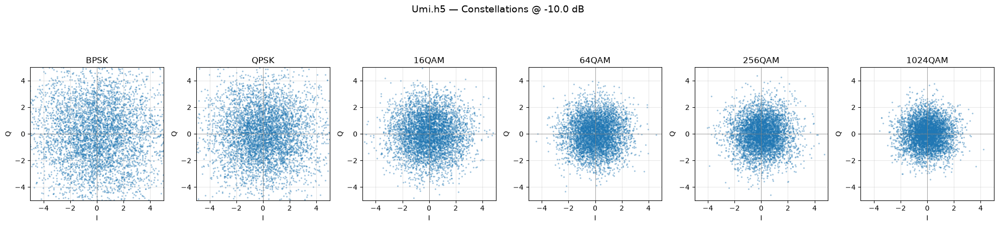

In [15]:
limit_neg10db = get_global_limit(target_snr=-10.0, mods_to_check=MOD_NAMES)
print(f"Global axis limit @ -10 dB: {limit_neg10db:.3f}")

for file in FILES:
    plot_constellations(file, target_snr=-10.0, axis_limit=5, n_symbols_per_mod=5)

## 11b. Side-by-side SNR comparison for 64QAM across files

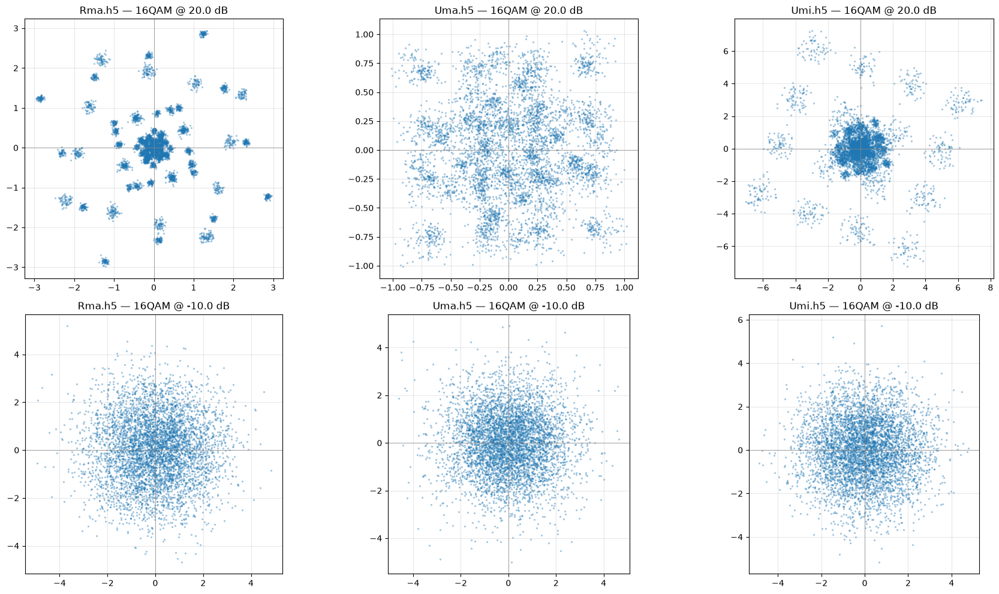

In [16]:
compare_mod = '16QAM'
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for col, file in enumerate(FILES):
    with h5py.File(file, 'r') as f:
        data = f["Data"][:]
        mods = f["Mods"][:]
        snrs = f["SNRs"][:]

    mod_idx = np.argmax(mods, axis=1)
    mod_labels = np.array(MOD_NAMES)[mod_idx]

    for row, snr in enumerate([20.0, -10.0]):
        mask = np.isclose(snrs, snr) & (mod_labels == compare_mod)
        sig = data[mask][:5].flatten()
        ax = axes[row, col]
        ax.scatter(sig.real, sig.imag, s=2, alpha=0.3)
        ax.axhline(0, color='gray', lw=0.5)
        ax.axvline(0, color='gray', lw=0.5)
        ax.set_title(f"{Path(file).name} — {compare_mod} @ {snr} dB")
        ax.set_aspect('equal')
        ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 12. Fading Severity: Amplitude vs Time for a single vector

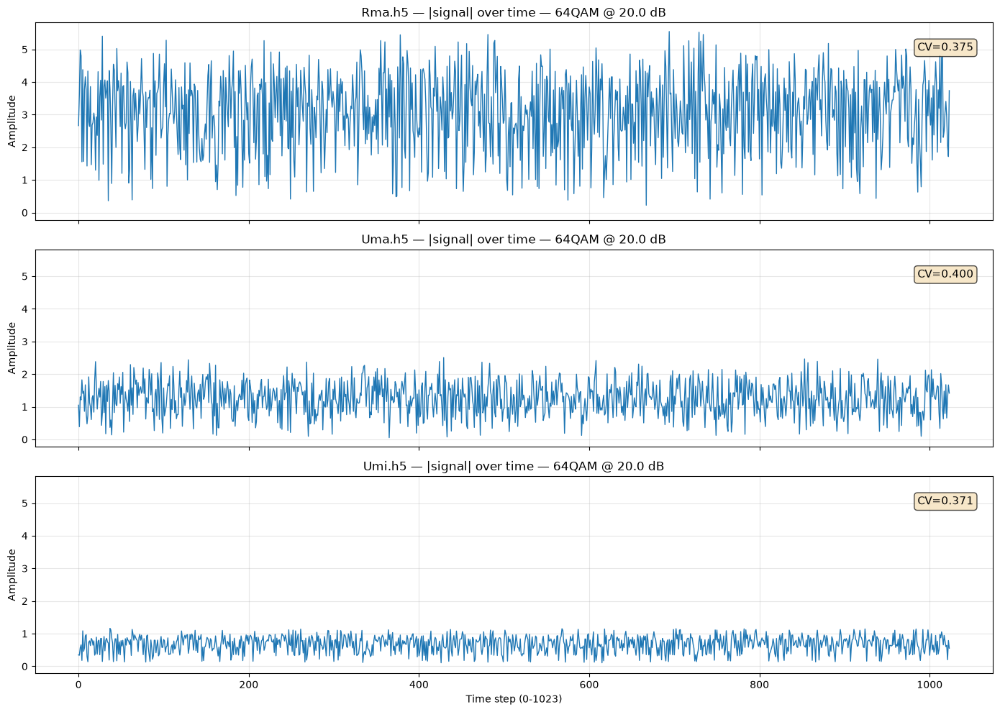

In [17]:
def plot_amplitude_trace(mod='16QAM', target_snr=20.0, vector_idx=0):
    fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True, sharey=True)

    for ax, file in zip(axes, FILES):
        with h5py.File(file, 'r') as f:
            data = f["Data"][:]
            mods = f["Mods"][:]
            snrs = f["SNRs"][:]

        mod_idx = np.argmax(mods, axis=1)
        mod_labels = np.array(MOD_NAMES)[mod_idx]
        mask = np.isclose(snrs, target_snr) & (mod_labels == mod)

        vec = data[mask][vector_idx]  # (1024,) complex, one full vector
        amplitude = np.abs(vec)

        ax.plot(amplitude, lw=1)
        ax.set_title(f"{Path(file).name} — |signal| over time — {mod} @ {target_snr} dB")
        ax.set_ylabel("Amplitude")
        ax.grid(alpha=0.3)
        # coefficient of variation as a numeric "how bursty is the fading" metric
        cv = np.std(amplitude) / np.mean(amplitude)
        ax.text(0.98, 0.9, f"CV={cv:.3f}", transform=ax.transAxes,
                ha='right', va='top', fontsize=11,
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))

    axes[-1].set_xlabel("Time step (0-1023)")
    plt.tight_layout()
    plt.show()

plot_amplitude_trace(mod='64QAM', target_snr=20.0, vector_idx=0)

## 13. Fading severity, quantified across many vectors

In [18]:
def fading_cv_summary(mod='64QAM', target_snr=20.0, n_vectors=200):
    print(f"Coefficient of Variation of |amplitude| within-vector, {mod} @ {target_snr} dB, n={n_vectors} vectors")
    for file in FILES:
        with h5py.File(file, 'r') as f:
            data = f["Data"][:]
            mods = f["Mods"][:]
            snrs = f["SNRs"][:]

        mod_idx = np.argmax(mods, axis=1)
        mod_labels = np.array(MOD_NAMES)[mod_idx]
        mask = np.isclose(snrs, target_snr) & (mod_labels == mod)

        vecs = data[mask][:n_vectors]
        amps = np.abs(vecs)  # (n_vectors, 1024)
        cvs = np.std(amps, axis=1) / np.mean(amps, axis=1)

        print(f"  {Path(file).name:12s}: mean CV = {cvs.mean():.4f}, std across vectors = {cvs.std():.4f}")

fading_cv_summary(mod='64QAM', target_snr=20.0, n_vectors=200)

Coefficient of Variation of |amplitude| within-vector, 64QAM @ 20.0 dB, n=200 vectors
  Rma.h5      : mean CV = 0.3807, std across vectors = 0.0297
  Uma.h5      : mean CV = 0.4219, std across vectors = 0.0422
  Umi.h5      : mean CV = 0.4196, std across vectors = 0.0444


Rma's fading behavior is not just calmer on average but more consistent vector-to-vector

The gap (Rma ~0.39 vs Uma/Umi ~0.42) is several times larger than the vector-to-vector std (0.03–0.04)

## 14. Phase Scatter Spread: Rma vs Umi @ 10 dB

In [19]:
def fading_cv_at_snr(mod='64QAM', target_snr=10.0, n_vectors=200):
    print(f"Per-vector CV of |amplitude|, {mod} @ {target_snr} dB, n={n_vectors} vectors")
    results = {}
    for file in FILES:
        with h5py.File(file, 'r') as f:
            data = f["Data"][:]
            mods = f["Mods"][:]
            snrs = f["SNRs"][:]

        mod_idx = np.argmax(mods, axis=1)
        mod_labels = np.array(MOD_NAMES)[mod_idx]
        mask = np.isclose(snrs, target_snr) & (mod_labels == mod)

        vecs = data[mask][:n_vectors]
        amps = np.abs(vecs)  # (n_vectors, 1024)
        cvs = np.std(amps, axis=1) / np.mean(amps, axis=1)  # per-vector, then we'll aggregate

        results[Path(file).stem] = cvs
        print(f"  {Path(file).name:12s}: mean CV = {cvs.mean():.4f}, std across vectors = {cvs.std():.4f}")

    return results

cv_10db = fading_cv_at_snr(mod='64QAM', target_snr=10.0, n_vectors=200)

Per-vector CV of |amplitude|, 64QAM @ 10.0 dB, n=200 vectors
  Rma.h5      : mean CV = 0.3907, std across vectors = 0.0356
  Uma.h5      : mean CV = 0.4280, std across vectors = 0.0420
  Umi.h5      : mean CV = 0.4254, std across vectors = 0.0422


## 14c. Same metric, same modulation, across multiple SNRs

In [20]:
for snr in [20.0, 10.0, 0.0]:
    print(f"\n=== SNR = {snr} dB ===")
    fading_cv_at_snr(mod='64QAM', target_snr=snr, n_vectors=200)


=== SNR = 20.0 dB ===
Per-vector CV of |amplitude|, 64QAM @ 20.0 dB, n=200 vectors
  Rma.h5      : mean CV = 0.3807, std across vectors = 0.0297
  Uma.h5      : mean CV = 0.4219, std across vectors = 0.0422
  Umi.h5      : mean CV = 0.4196, std across vectors = 0.0444

=== SNR = 10.0 dB ===
Per-vector CV of |amplitude|, 64QAM @ 10.0 dB, n=200 vectors
  Rma.h5      : mean CV = 0.3907, std across vectors = 0.0356
  Uma.h5      : mean CV = 0.4280, std across vectors = 0.0420
  Umi.h5      : mean CV = 0.4254, std across vectors = 0.0422

=== SNR = 0.0 dB ===
Per-vector CV of |amplitude|, 64QAM @ 0.0 dB, n=200 vectors
  Rma.h5      : mean CV = 0.4290, std across vectors = 0.0437
  Uma.h5      : mean CV = 0.4584, std across vectors = 0.0423
  Umi.h5      : mean CV = 0.4561, std across vectors = 0.0428


## 15. Finally Documenting the Dataset

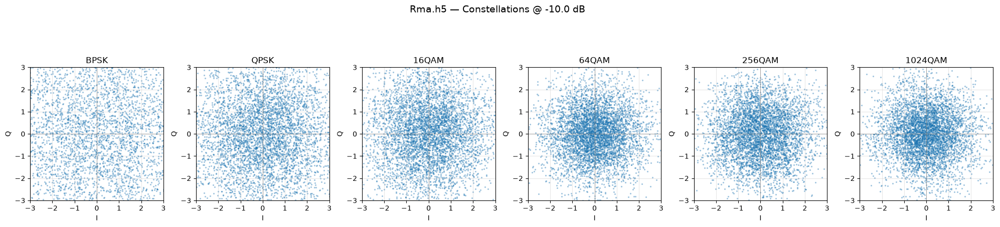

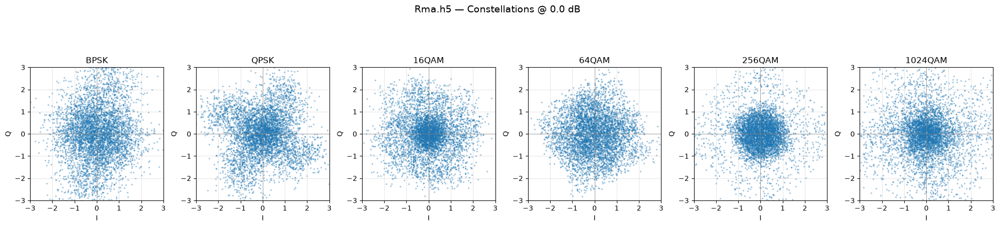

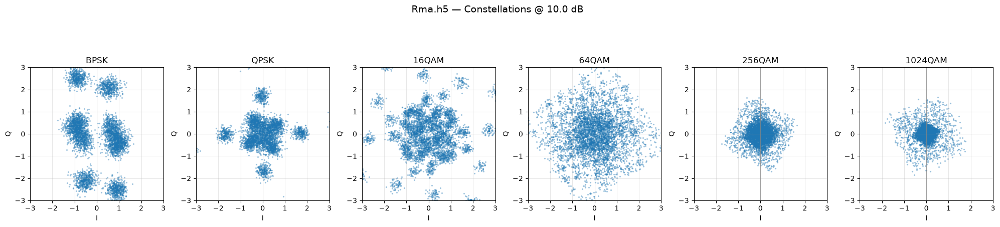

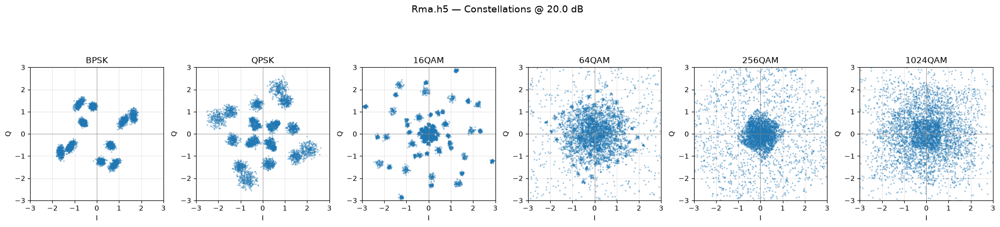

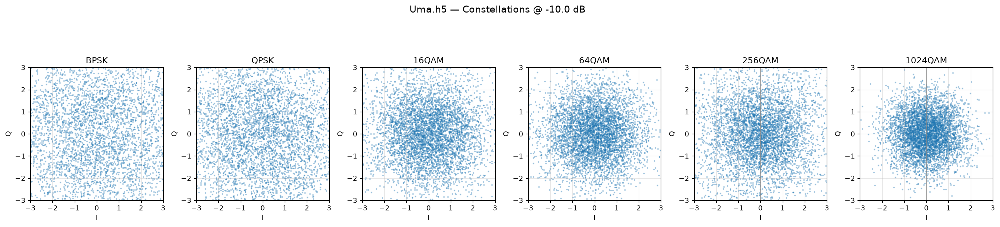

...

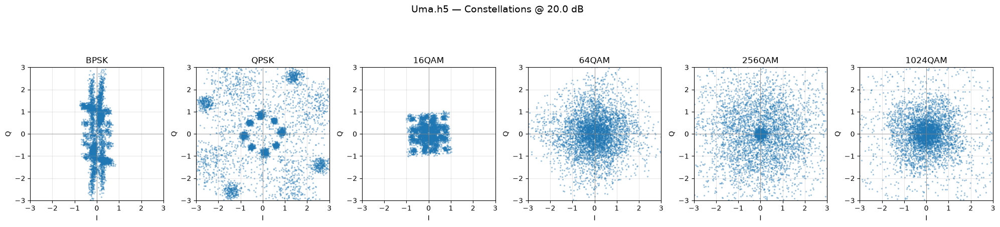

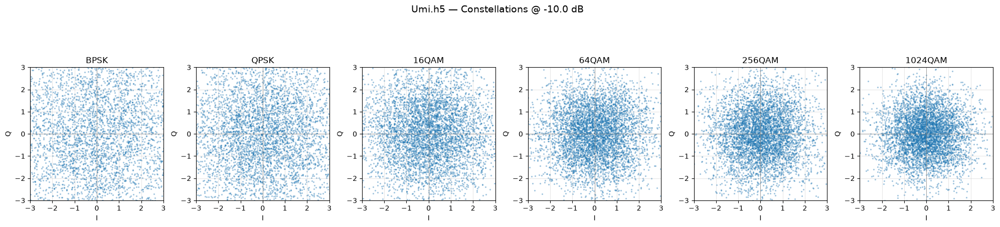

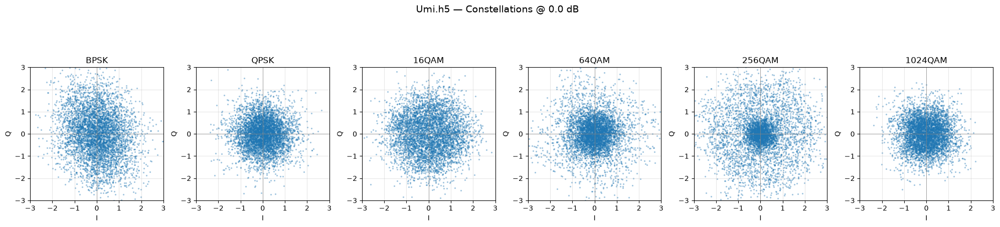

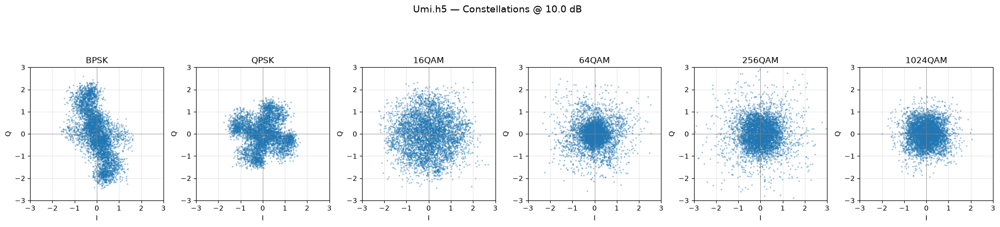

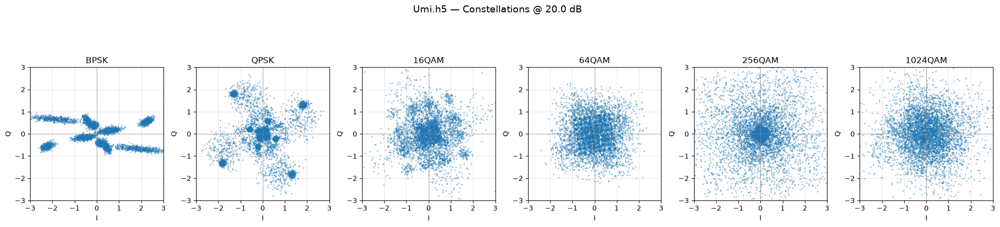

In [21]:
REQUIRED_SNRS = [-10.0, 0.0, 10.0, 20.0]

for file in FILES:
    for snr in REQUIRED_SNRS:
        plot_constellations(file, target_snr=snr, axis_limit=3, n_symbols_per_mod=5)

Mean fading CV by file and SNR — 64QAM

File     Rma     Uma     Umi
SNR                         
-10   0.4951  0.5058  0.5033
-8    0.4826  0.4960  0.4961
-6    0.4718  0.4866  0.4857
-4    0.4594  0.4781  0.4773
-2    0.4458  0.4652  0.4656
 0    0.4322  0.4586  0.4569
 2    0.4230  0.4470  0.4468
 4    0.4115  0.4414  0.4386
 6    0.4004  0.4364  0.4307
 8    0.3947  0.4301  0.4267
 10   0.3892  0.4289  0.4235
 12   0.3866  0.4271  0.4211
 14   0.3844  0.4232  0.4181
 16   0.3822  0.4212  0.4169
 18   0.3804  0.4207  0.4160
 20   0.3794  0.4236  0.4148


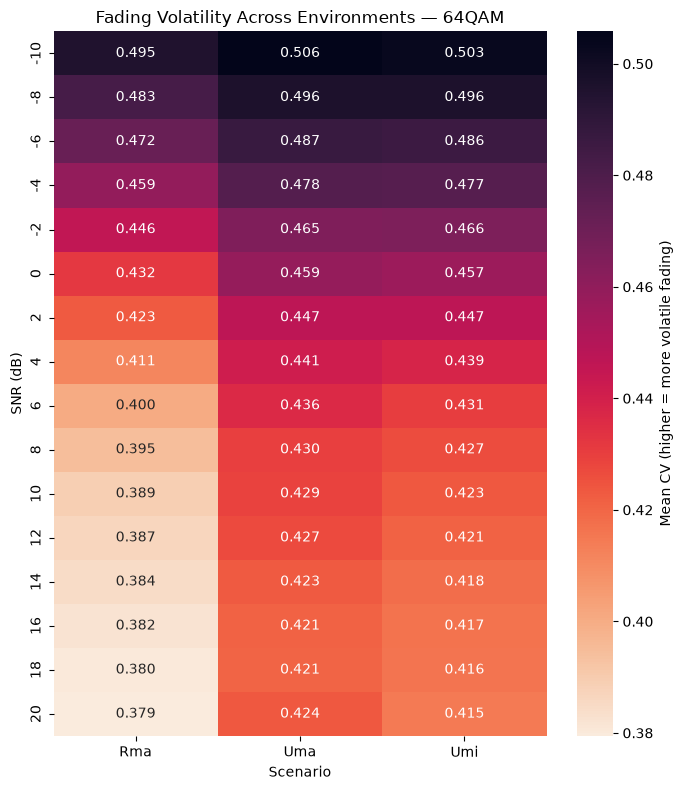

In [22]:
summary_mod = '64QAM'
all_snrs = EXPECTED_SNRS

rows = []

for file in FILES:
    with h5py.File(file, 'r') as f:
        data = f["Data"][:]
        mods = f["Mods"][:]
        snrs = f["SNRs"][:]

    mod_idx = np.argmax(mods, axis=1)
    mod_labels = np.array(MOD_NAMES)[mod_idx]

    for snr in all_snrs:
        mask = np.isclose(snrs, snr) & (mod_labels == summary_mod)
        vecs = data[mask]
        amps = np.abs(vecs)
        cvs = np.std(amps, axis=1) / np.mean(amps, axis=1)
        rows.append({
            "File": Path(file).stem,
            "SNR": snr,
            "MeanCV": cvs.mean()
        })

summary_df = pd.DataFrame(rows)
pivot_table = summary_df.pivot(index="SNR", columns="File", values="MeanCV")

print(f"Mean fading CV by file and SNR — {summary_mod}\n")
print(pivot_table.round(4))

plt.figure(figsize=(7, 8))
sns.heatmap(pivot_table, annot=True, fmt='.3f', cmap='rocket_r',
            cbar_kws={'label': 'Mean CV (higher = more volatile fading)'})
plt.title(f"Fading Volatility Across Environments — {summary_mod}")
plt.xlabel("Scenario")
plt.ylabel("SNR (dB)")
plt.tight_layout()
plt.show()